In [1]:
# Step 4: Model Development and Evaluation

import os
import json
import joblib
import numpy as np
import pandas as pd

# Reproducibility
RANDOM_STATE = 42

# Create folders for saved artefacts
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

print("Step 4 environment ready.")
print("Random state:", RANDOM_STATE)

Step 4 environment ready.
Random state: 42


In [2]:
# Load the prepared datasets from Step 3

X_train_selected = joblib.load("artifacts/X_train_selected.joblib")
X_test_selected = joblib.load("artifacts/X_test_selected.joblib")
y_train = joblib.load("artifacts/y_train.joblib")
y_test = joblib.load("artifacts/y_test.joblib")
selected_features = joblib.load("artifacts/selected_features.joblib")

print("Training set:", X_train_selected.shape)
print("Test set:", X_test_selected.shape)
print("Selected features:", len(selected_features))
print("Dropout rate in training set:", round(y_train.mean(), 3))
print("Dropout rate in test set:", round(y_test.mean(), 3))

Training set: (3539, 49)
Test set: (885, 49)
Selected features: 49
Dropout rate in training set: 0.321
Dropout rate in test set: 0.321


In [3]:
# Evaluation metrics for the binary dropout classification task

from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Calculate and display the key evaluation metrics.
    Dropout (1) is treated as the positive class.
    """
    
    roc_auc = roc_auc_score(y_true, y_prob)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    
    return {
        "Model": model_name,
        "ROC-AUC": roc_auc,
        "Recall": recall,
        "F1-score": f1,
        "Precision": precision,
        "Accuracy": accuracy
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


In [4]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(X_train_selected, y_train)

y_pred_logistic = logistic_model.predict(X_test_selected)
y_prob_logistic = logistic_model.predict_proba(X_test_selected)[:, 1]

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

Model: Logistic Regression
ROC-AUC:   0.8182
Recall:    0.4859
F1-score:  0.6026
Precision: 0.7931
Accuracy:  0.7944


In [5]:
# Model 2: Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=5,
    min_samples_leaf=10
)

decision_tree_model.fit(X_train_selected, y_train)

y_pred_tree = decision_tree_model.predict(X_test_selected)
y_prob_tree = decision_tree_model.predict_proba(X_test_selected)[:, 1]

decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree,
    y_prob_tree
)

Model: Decision Tree
ROC-AUC:   0.7929
Recall:    0.5141
F1-score:  0.5984
Precision: 0.7157
Accuracy:  0.7785


In [6]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(X_train_selected, y_train)

y_pred_rf = random_forest_model.predict(X_test_selected)
y_prob_rf = random_forest_model.predict_proba(X_test_selected)[:, 1]

random_forest_results = evaluate_model(
    "Random Forest", y_test, y_pred_rf, y_prob_rf
)

Model: Random Forest
ROC-AUC:   0.8155
Recall:    0.6972
F1-score:  0.6481
Precision: 0.6055
Accuracy:  0.7571


In [7]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_model.fit(X_train_selected, y_train)

y_pred_xgb = xgb_model.predict(X_test_selected)
y_prob_xgb = xgb_model.predict_proba(X_test_selected)[:, 1]

xgb_results = evaluate_model(
    "XGBoost", y_test, y_pred_xgb, y_prob_xgb
)

Model: XGBoost
ROC-AUC:   0.8256
Recall:    0.5000
F1-score:  0.6055
Precision: 0.7676
Accuracy:  0.7910


In [8]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_selected, y_train)

y_pred_svm = svm_model.predict(X_test_selected)
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

svm_results = evaluate_model(
    "SVM", y_test, y_pred_svm, y_prob_svm
)

C:\Users\Rufus1503\.conda\envs\capstone\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Model: SVM
ROC-AUC:   0.8140
Recall:    0.6690
F1-score:  0.6365
Precision: 0.6070
Accuracy:  0.7548


In [9]:
model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    xgb_results,
    svm_results
])

model_comparison = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,ROC-AUC,Recall,F1-score,Precision,Accuracy
0,XGBoost,0.825625,0.500000,0.605544,0.767568,0.790960
1,Logistic Regression,0.818249,0.485915,0.602620,0.793103,0.794350
2,Random Forest,0.815507,0.697183,0.648118,0.605505,0.757062
3,SVM,0.813960,0.669014,0.636516,0.607029,0.754802
4,Decision Tree,0.792869,0.514085,0.598361,0.715686,0.778531


In [10]:
joblib.dump(logistic_model, "models/logistic_regression.joblib")
joblib.dump(decision_tree_model, "models/decision_tree.joblib")
joblib.dump(random_forest_model, "models/random_forest.joblib")
joblib.dump(xgb_model, "models/xgboost.joblib")
joblib.dump(svm_model, "models/svm.joblib")

model_comparison.to_csv(
    "artifacts/model_comparison.csv",
    index=False
)

print("All trained models and comparison results saved successfully.")

All trained models and comparison results saved successfully.


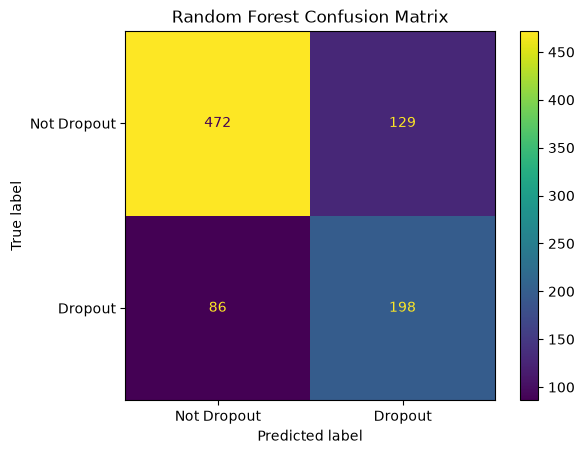

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Not Dropout", "Dropout"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

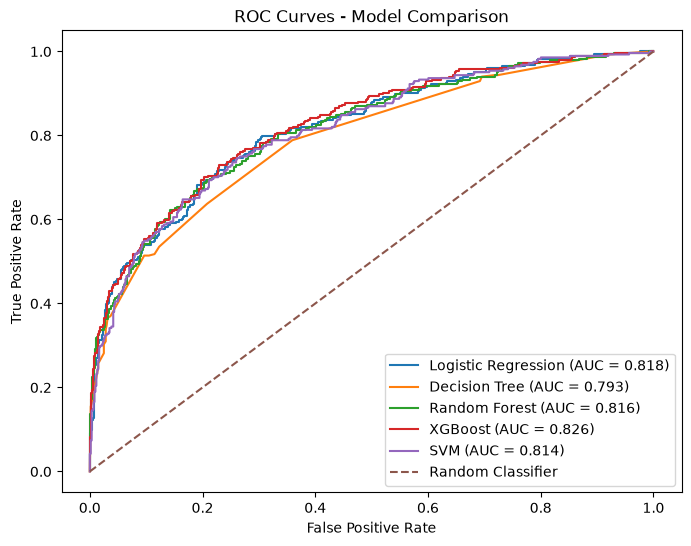

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models_for_roc = {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "SVM": y_prob_svm
}

plt.figure(figsize=(8, 6))

for model_name, y_prob in models_for_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Recall": recall_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Recall,Precision,F1-score
0,0.30,0.904930,0.430486,0.583428
1,0.35,0.869718,0.459963,0.601705
2,0.40,0.816901,0.497854,0.618667
3,0.45,0.757042,0.544304,0.633284
4,0.50,0.697183,0.605505,0.648118
5,0.55,0.623239,0.667925,0.644809
6,0.60,0.535211,0.723810,0.615385
7,0.65,0.471831,0.757062,0.581345
8,0.70,0.397887,0.818841,0.535545


In [14]:
selected_threshold = 0.50

y_pred_final = (y_prob_rf >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_final
).ravel()

dropout_identified = tp
actual_dropout = tp + fn
intervention_coverage = dropout_identified / actual_dropout

print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Actual dropout students: {actual_dropout}")
print(f"Dropout students correctly identified: {dropout_identified}")
print(f"Dropout identification rate: {intervention_coverage:.2%}")
print(f"Students flagged for intervention: {tp + fp}")

Selected threshold: 0.50
Actual dropout students: 284
Dropout students correctly identified: 198
Dropout identification rate: 69.72%
Students flagged for intervention: 327


In [15]:
final_config = {
    "selected_model": "Random Forest",
    "operating_threshold": float(selected_threshold),
    "roc_auc": float(random_forest_results["ROC-AUC"]),
    "recall": float(random_forest_results["Recall"]),
    "f1_score": float(random_forest_results["F1-score"]),
    "precision": float(random_forest_results["Precision"]),
    "accuracy": float(random_forest_results["Accuracy"]),
    "actual_dropout_students": int(actual_dropout),
    "dropout_students_correctly_identified": int(dropout_identified),
    "intervention_coverage": float(intervention_coverage),
    "students_flagged_for_intervention": int(tp + fp)
}

with open("artifacts/final_model_config.json", "w") as f:
    json.dump(final_config, f, indent=4)

joblib.dump(y_pred_final, "artifacts/final_predictions.joblib")

print("Final model configuration and predictions saved successfully.")
print(f"Selected model: {final_config['selected_model']}")
print(f"Operating threshold: {final_config['operating_threshold']:.2f}")
print(f"Intervention coverage: {final_config['intervention_coverage']:.2%}")

Final model configuration and predictions saved successfully.
Selected model: Random Forest
Operating threshold: 0.50
Intervention coverage: 69.72%


In [16]:
final_model_summary = {
    "Recommended Model": "Random Forest",
    "Reason": (
        "Random Forest provides the strongest balance between identifying "
        "dropout students and maintaining precision. It achieved the highest "
        "dropout recall (69.72%) and highest F1-score (0.6481) among the "
        "tested models, while maintaining a strong ROC-AUC (0.8155)."
    ),
    "Operating Threshold": 0.50,
    "Dropout Recall": 0.697183,
    "F1-score": 0.648118,
    "ROC-AUC": 0.815507,
    "Precision": 0.605505,
    "Accuracy": 0.757062,
    "Intervention Coverage": 0.697183
}

print("FINAL MODEL RECOMMENDATION")
print("-" * 40)
print(f"Model: {final_model_summary['Recommended Model']}")
print(f"Operating threshold: {final_model_summary['Operating Threshold']:.2f}")
print(f"ROC-AUC: {final_model_summary['ROC-AUC']:.4f}")
print(f"Dropout Recall: {final_model_summary['Dropout Recall']:.4f}")
print(f"F1-score: {final_model_summary['F1-score']:.4f}")
print(f"Precision: {final_model_summary['Precision']:.4f}")
print(f"Accuracy: {final_model_summary['Accuracy']:.4f}")
print(f"Intervention Coverage: {final_model_summary['Intervention Coverage']:.2%}")
print()
print("Recommendation:")
print(final_model_summary["Reason"])

FINAL MODEL RECOMMENDATION
----------------------------------------
Model: Random Forest
Operating threshold: 0.50
ROC-AUC: 0.8155
Dropout Recall: 0.6972
F1-score: 0.6481
Precision: 0.6055
Accuracy: 0.7571
Intervention Coverage: 69.72%

Recommendation:
Random Forest provides the strongest balance between identifying dropout students and maintaining precision. It achieved the highest dropout recall (69.72%) and highest F1-score (0.6481) among the tested models, while maintaining a strong ROC-AUC (0.8155).


In [17]:
import json

step4_results = {
    "model_comparison": model_comparison.to_dict(orient="records"),
    "recommended_model": final_model_summary,
    "threshold_analysis": threshold_results.to_dict(orient="records")
}

with open("artifacts/step4_results.json", "w") as f:
    json.dump(step4_results, f, indent=4)

print("Complete Step 4 results saved successfully.")
print("Saved file: artifacts/step4_results.json")

Complete Step 4 results saved successfully.
Saved file: artifacts/step4_results.json


In [18]:
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,cat__Tuition fees up to date_0,0.125174
1,num__Age at enrollment,0.113383
2,cat__Tuition fees up to date_1,0.112490
3,num__Financial_Risk_Flag,0.109881
4,cat__Scholarship holder_0,0.058925
5,cat__Scholarship holder_1,0.058634
6,num__Admission grade,0.054042
7,num__Previous qualification (grade),0.047437
8,cat__Application mode_1,0.034986
9,cat__Gender_1,0.031111


In [19]:
feature_importance.to_csv(
    "artifacts/random_forest_feature_importance.csv",
    index=False
)

print("Random Forest feature importance saved successfully.")
print("Saved file: artifacts/random_forest_feature_importance.csv")

Random Forest feature importance saved successfully.
Saved file: artifacts/random_forest_feature_importance.csv


In [20]:
import os

required_models = [
    "logistic_regression.joblib",
    "decision_tree.joblib",
    "random_forest.joblib",
    "xgboost.joblib",
    "svm.joblib"
]

required_artifacts = [
    "model_comparison.csv",
    "final_model_config.json",
    "step4_results.json",
    "random_forest_feature_importance.csv",
    "final_predictions.joblib"
]

print("STEP 4 FINAL VERIFICATION")
print("-" * 40)

print("\nSaved models:")
for file in required_models:
    print(f"{file}: {'OK' if os.path.exists('models/' + file) else 'MISSING'}")

print("\nSaved artefacts:")
for file in required_artifacts:
    print(f"{file}: {'OK' if os.path.exists('artifacts/' + file) else 'MISSING'}")

print("\nStep 4 coding workflow completed successfully.")

STEP 4 FINAL VERIFICATION
----------------------------------------

Saved models:
logistic_regression.joblib: OK
decision_tree.joblib: OK
random_forest.joblib: OK
xgboost.joblib: OK
svm.joblib: OK

Saved artefacts:
model_comparison.csv: OK
final_model_config.json: OK
step4_results.json: OK
random_forest_feature_importance.csv: OK
final_predictions.joblib: OK

Step 4 coding workflow completed successfully.


In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_tuning_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 8, 10, 12, 15],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train_selected, y_train)

print("Random Forest tuning completed successfully.")
print("Best parameters:")
print(rf_random_search.best_params_)
print(f"Best cross-validation F1-score: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest tuning completed successfully.
Best parameters:
{'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10}
Best cross-validation F1-score: 0.6226


In [22]:
tuned_rf_model = rf_random_search.best_estimator_

y_pred_tuned_rf = tuned_rf_model.predict(X_test_selected)
y_prob_tuned_rf = tuned_rf_model.predict_proba(X_test_selected)[:, 1]

tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_tuned_rf,
    y_prob_tuned_rf
)

Model: Tuned Random Forest
ROC-AUC:   0.8108
Recall:    0.6972
F1-score:  0.6439
Precision: 0.5982
Accuracy:  0.7525


In [23]:
rf_comparison = pd.DataFrame([
    random_forest_results,
    tuned_rf_results
])

rf_comparison

,Model,ROC-AUC,Recall,F1-score,Precision,Accuracy
0,Random Forest,0.815507,0.697183,0.648118,0.605505,0.757062
1,Tuned Random Forest,0.810761,0.697183,0.643902,0.598187,0.752542


In [24]:
rf_tuning_results = {
    "baseline_model": random_forest_results,
    "tuned_model": tuned_rf_results,
    "best_parameters": rf_random_search.best_params_,
    "best_cv_f1_score": float(rf_random_search.best_score_),
    "final_selected_model": "Random Forest",
    "selection_reason": (
        "The tuned Random Forest did not outperform the baseline Random Forest "
        "on the held-out test set. The baseline model therefore remains the "
        "final selected model."
    )
}

with open("artifacts/random_forest_tuning.json", "w") as f:
    json.dump(rf_tuning_results, f, indent=4)

print("Random Forest tuning results saved successfully.")
print("Final selected model: Random Forest")

Random Forest tuning results saved successfully.
Final selected model: Random Forest


In [25]:
import os

required_models = [
    "logistic_regression.joblib",
    "decision_tree.joblib",
    "random_forest.joblib",
    "xgboost.joblib",
    "svm.joblib"
]

required_artifacts = [
    "model_comparison.csv",
    "final_model_config.json",
    "step4_results.json",
    "random_forest_feature_importance.csv",
    "final_predictions.joblib",
    "random_forest_tuning.json"
]

print("STEP 4 FINAL VERIFICATION")
print("-" * 40)

print("\nSaved models:")
for file in required_models:
    print(f"{file}: {'OK' if os.path.exists('models/' + file) else 'MISSING'}")

print("\nSaved artefacts:")
for file in required_artifacts:
    print(f"{file}: {'OK' if os.path.exists('artifacts/' + file) else 'MISSING'}")

print("\nStep 4 coding workflow completed successfully.")

STEP 4 FINAL VERIFICATION
----------------------------------------

Saved models:
logistic_regression.joblib: OK
decision_tree.joblib: OK
random_forest.joblib: OK
xgboost.joblib: OK
svm.joblib: OK

Saved artefacts:
model_comparison.csv: OK
final_model_config.json: OK
step4_results.json: OK
random_forest_feature_importance.csv: OK
final_predictions.joblib: OK
random_forest_tuning.json: OK

Step 4 coding workflow completed successfully.
